Saving Bank Marketing.csv to Bank Marketing (3).csv
LOADING DATASET
Shape: (41188, 21)  (41188 rows x 21 columns)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...

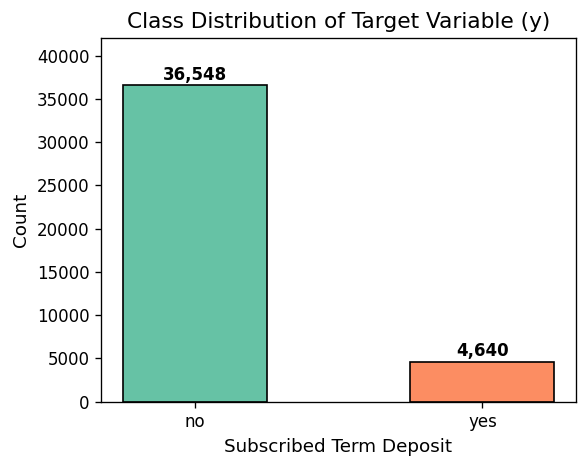

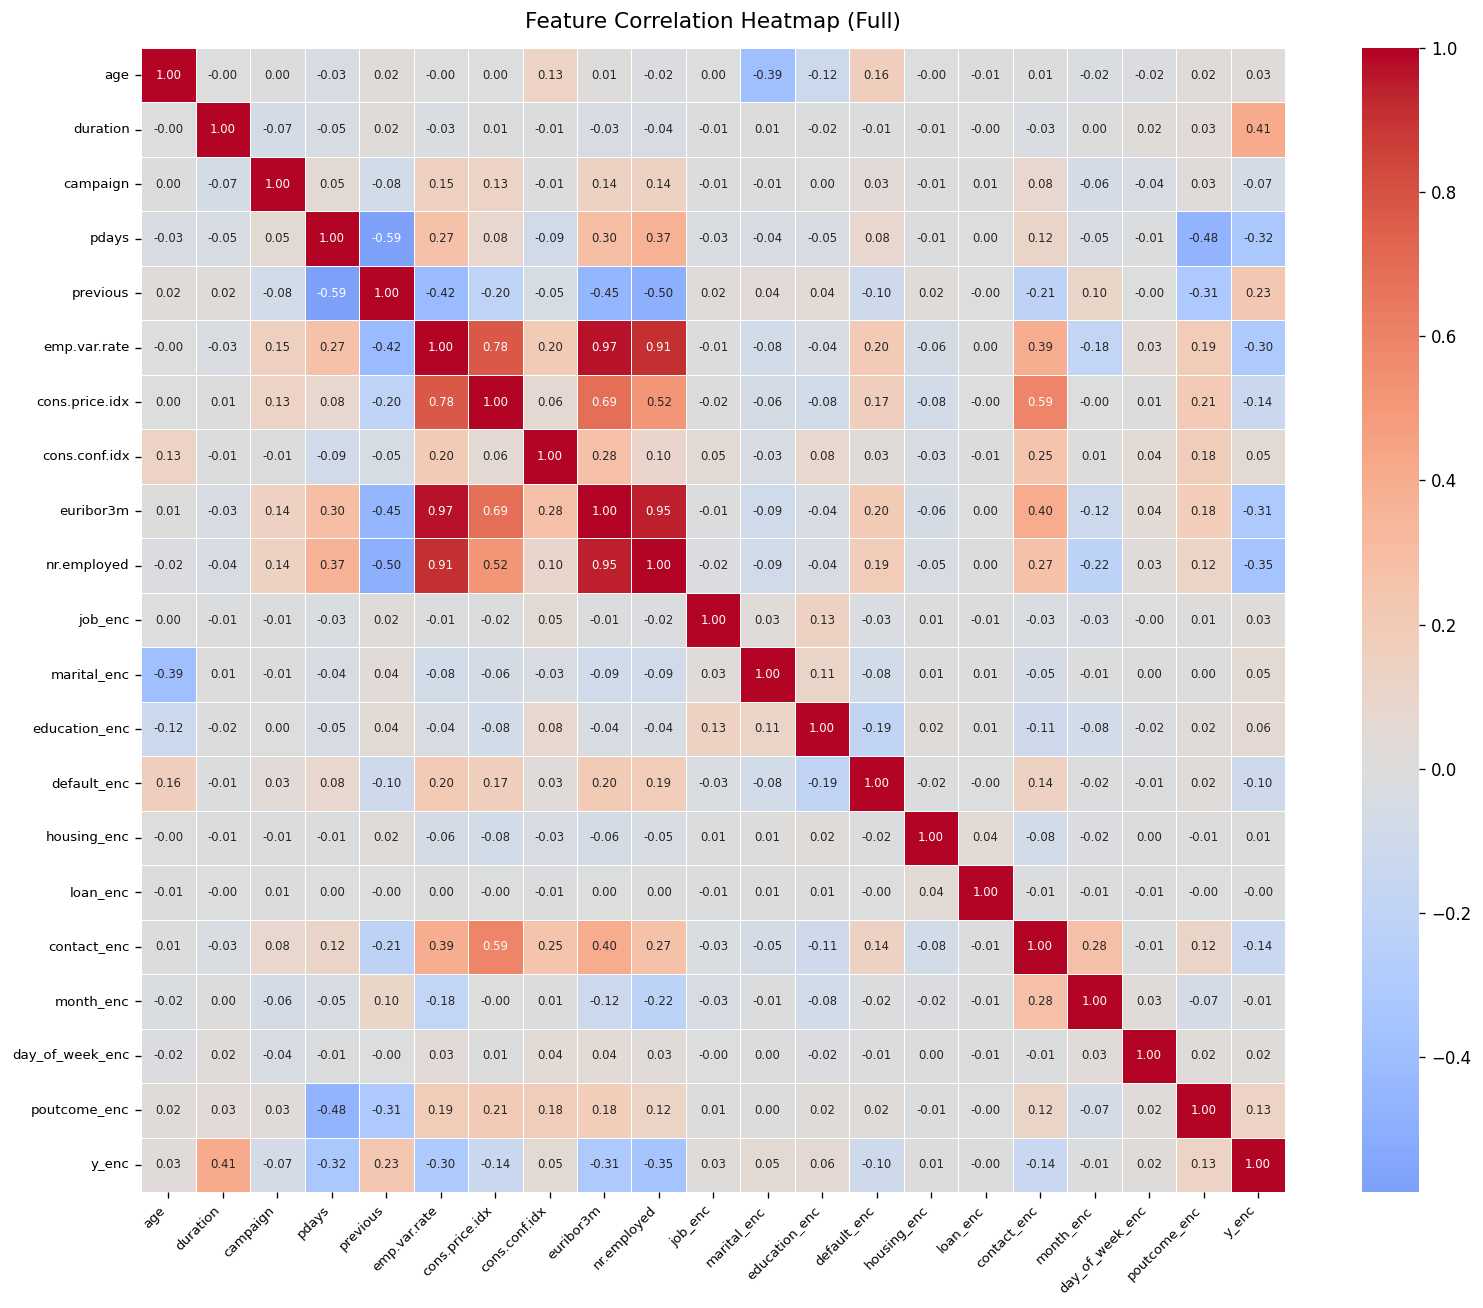

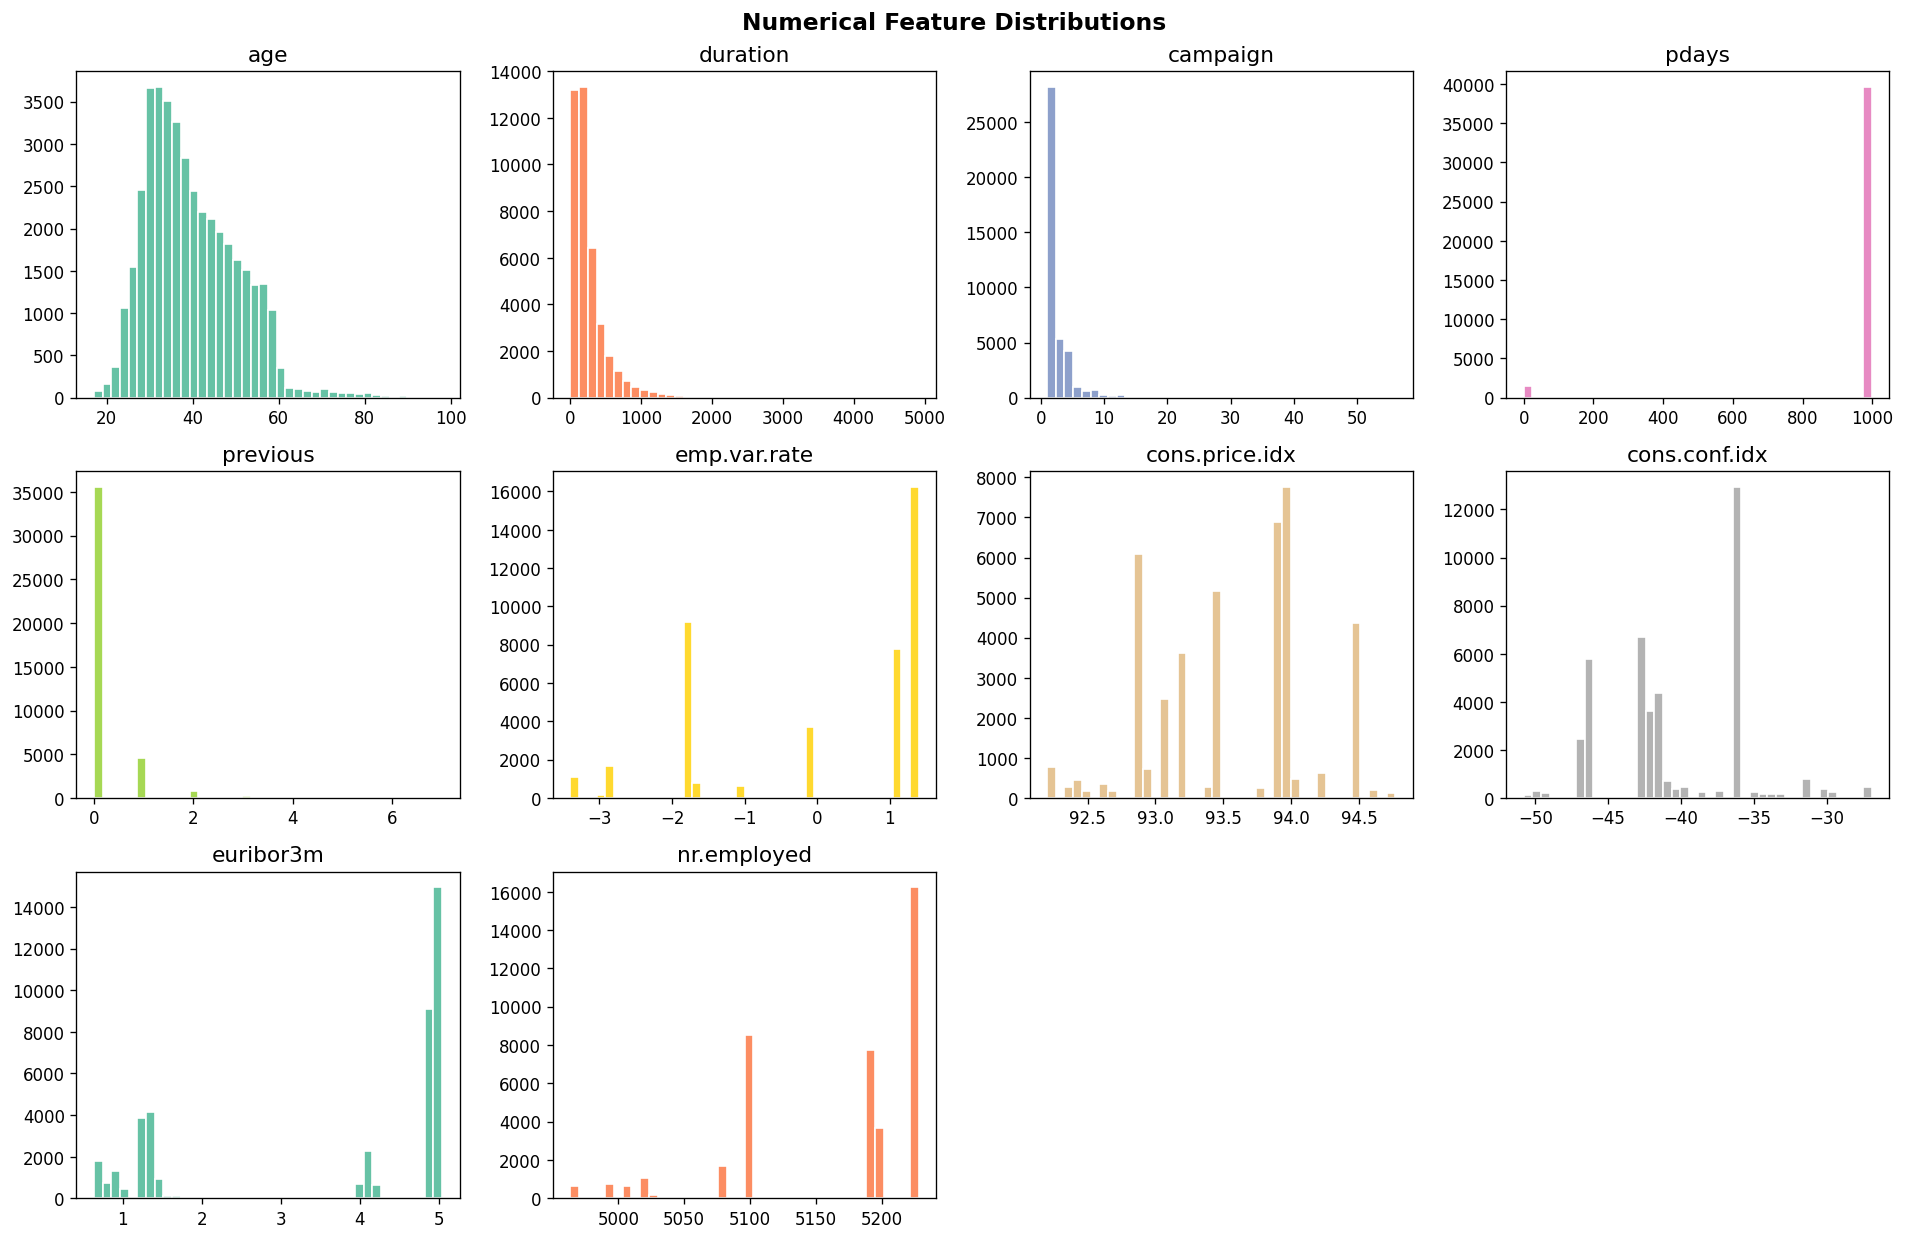

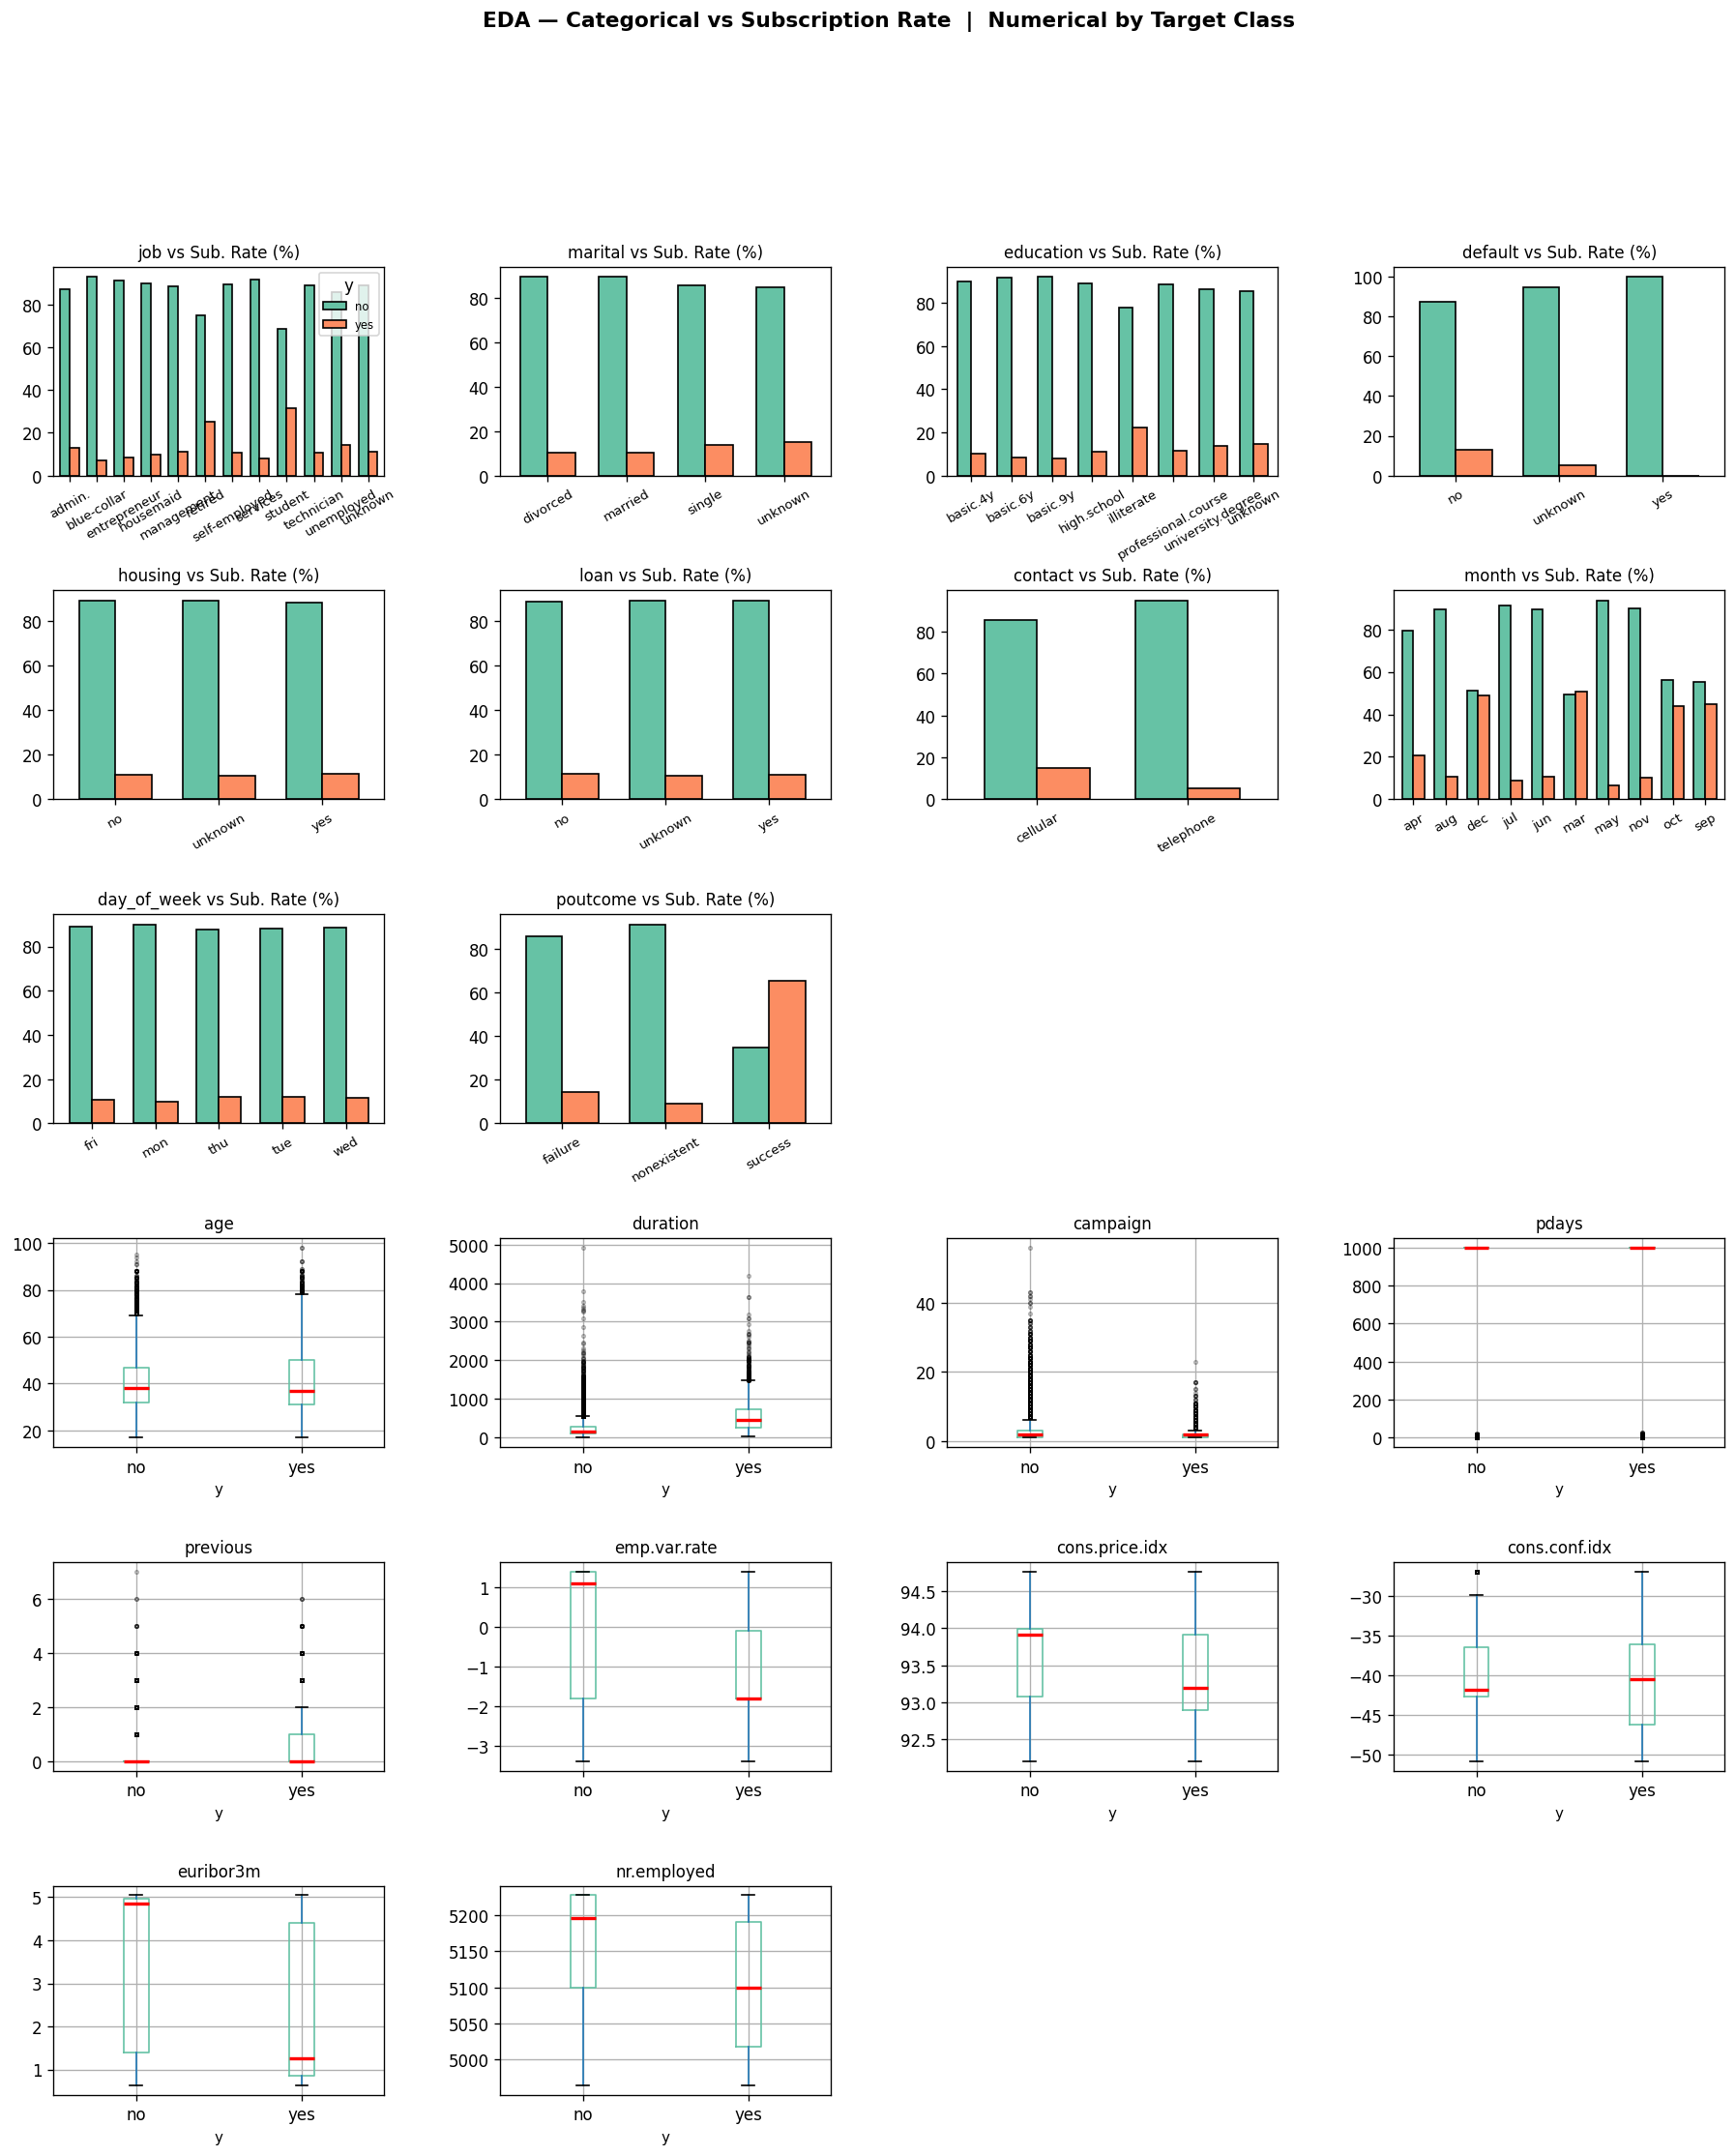


SECTION 3 - DATA PREPROCESSING

Missing values: 0 -> No action needed

Label Encoding categorical features:
  job: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
  marital: ['divorced', 'married', 'single', 'unknown']
  education: ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']
  default: ['no', 'unknown', 'yes']
  housing: ['no', 'unknown', 'yes']
  loan: ['no', 'unknown', 'yes']
  contact: ['cellular', 'telephone']
  month: ['apr', 'aug', 'dec', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
  day_of_week: ['fri', 'mon', 'thu', 'tue', 'wed']
  poutcome: ['failure', 'nonexistent', 'success']
  y: ['no', 'yes']

Features shape: (41188, 20)
StandardScaler applied - mean~0, std~1

SECTION 4 - DATASET SPLITTING
Train: 32950 samples  |  Test: 8238 samples
Train class ratio: {0: 29238, 1: 3712}
Test  class

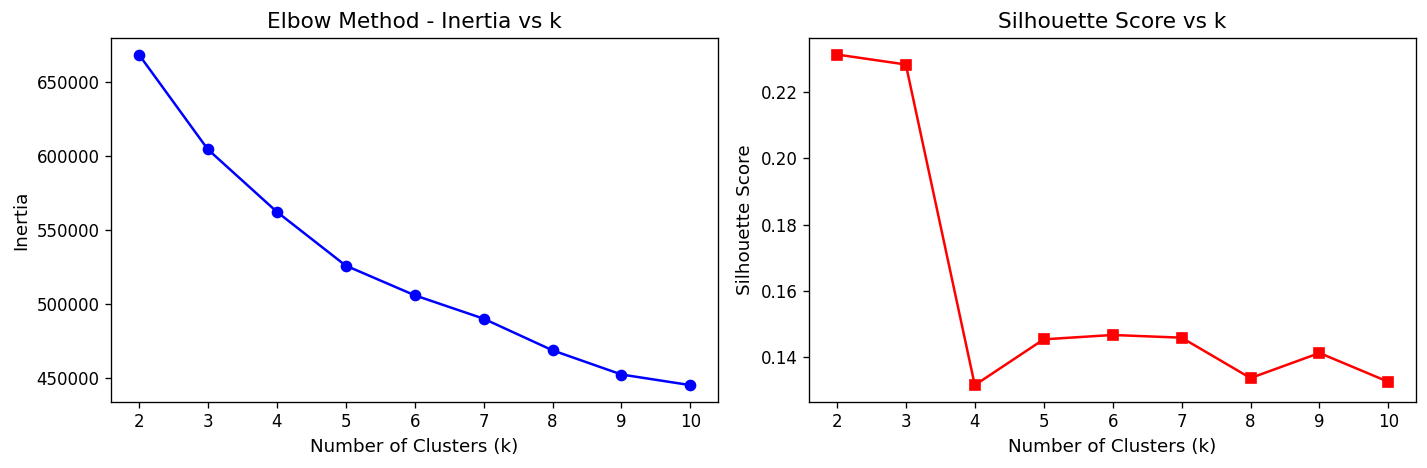

  Best k: 2  |  Silhouette Score: 0.2313

Cluster Composition vs True Labels:
         No (0)  Yes (1)
Cluster                 
0         10866     3326
1         25682     1314


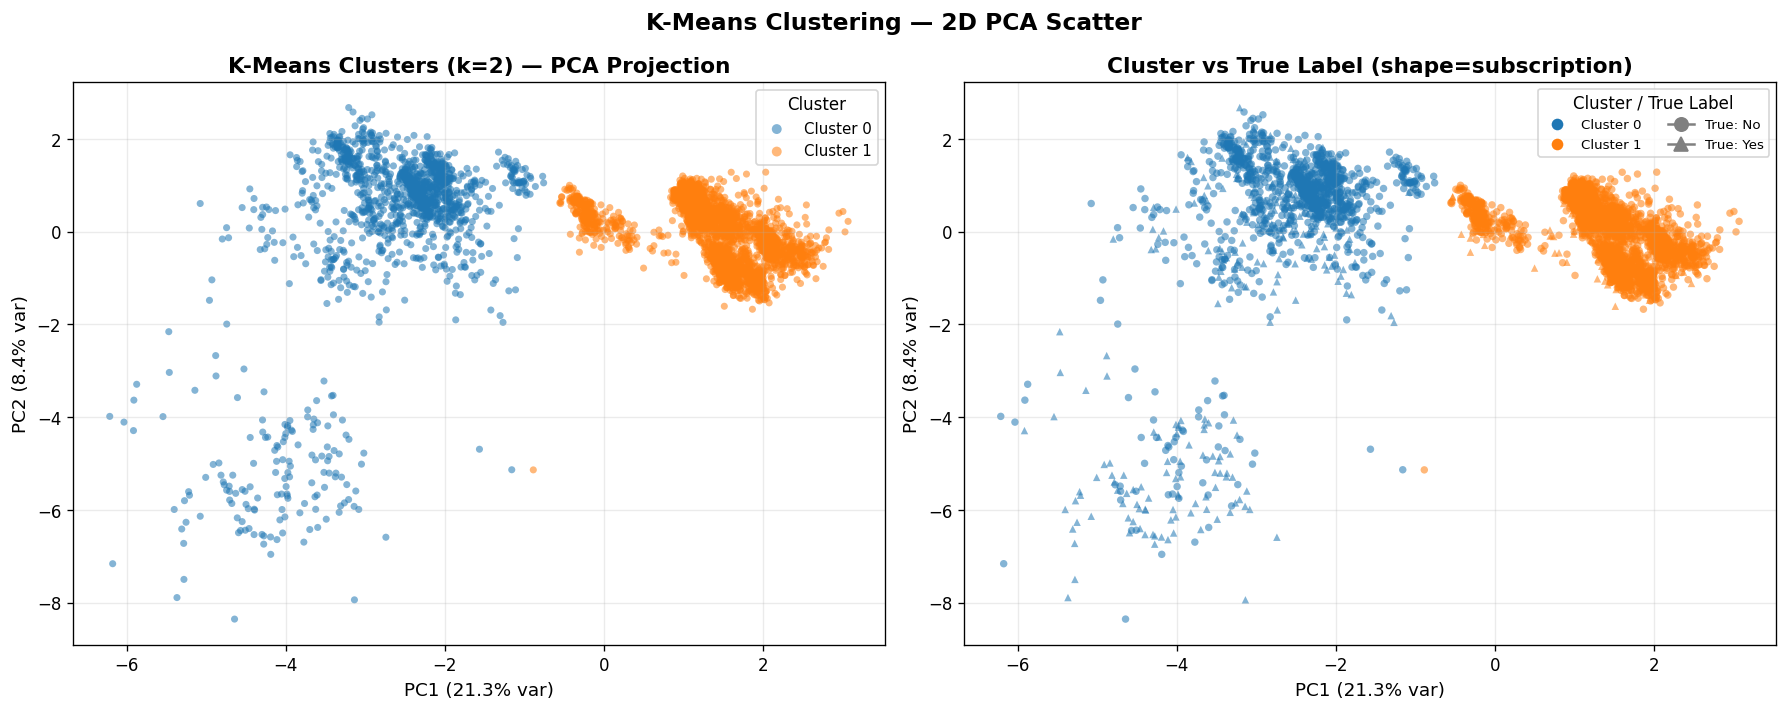


SECTION 6 - MODEL COMPARISON

Summary Table:
              Model Accuracy Precision Recall F1-Score    AUC
      Decision Tree   0.9136    0.6347 0.5485   0.5884 0.9227
Logistic Regression   0.8562    0.4303 0.8545   0.5724 0.9303
     Neural Network   0.9124    0.6580 0.4623   0.5430 0.9295


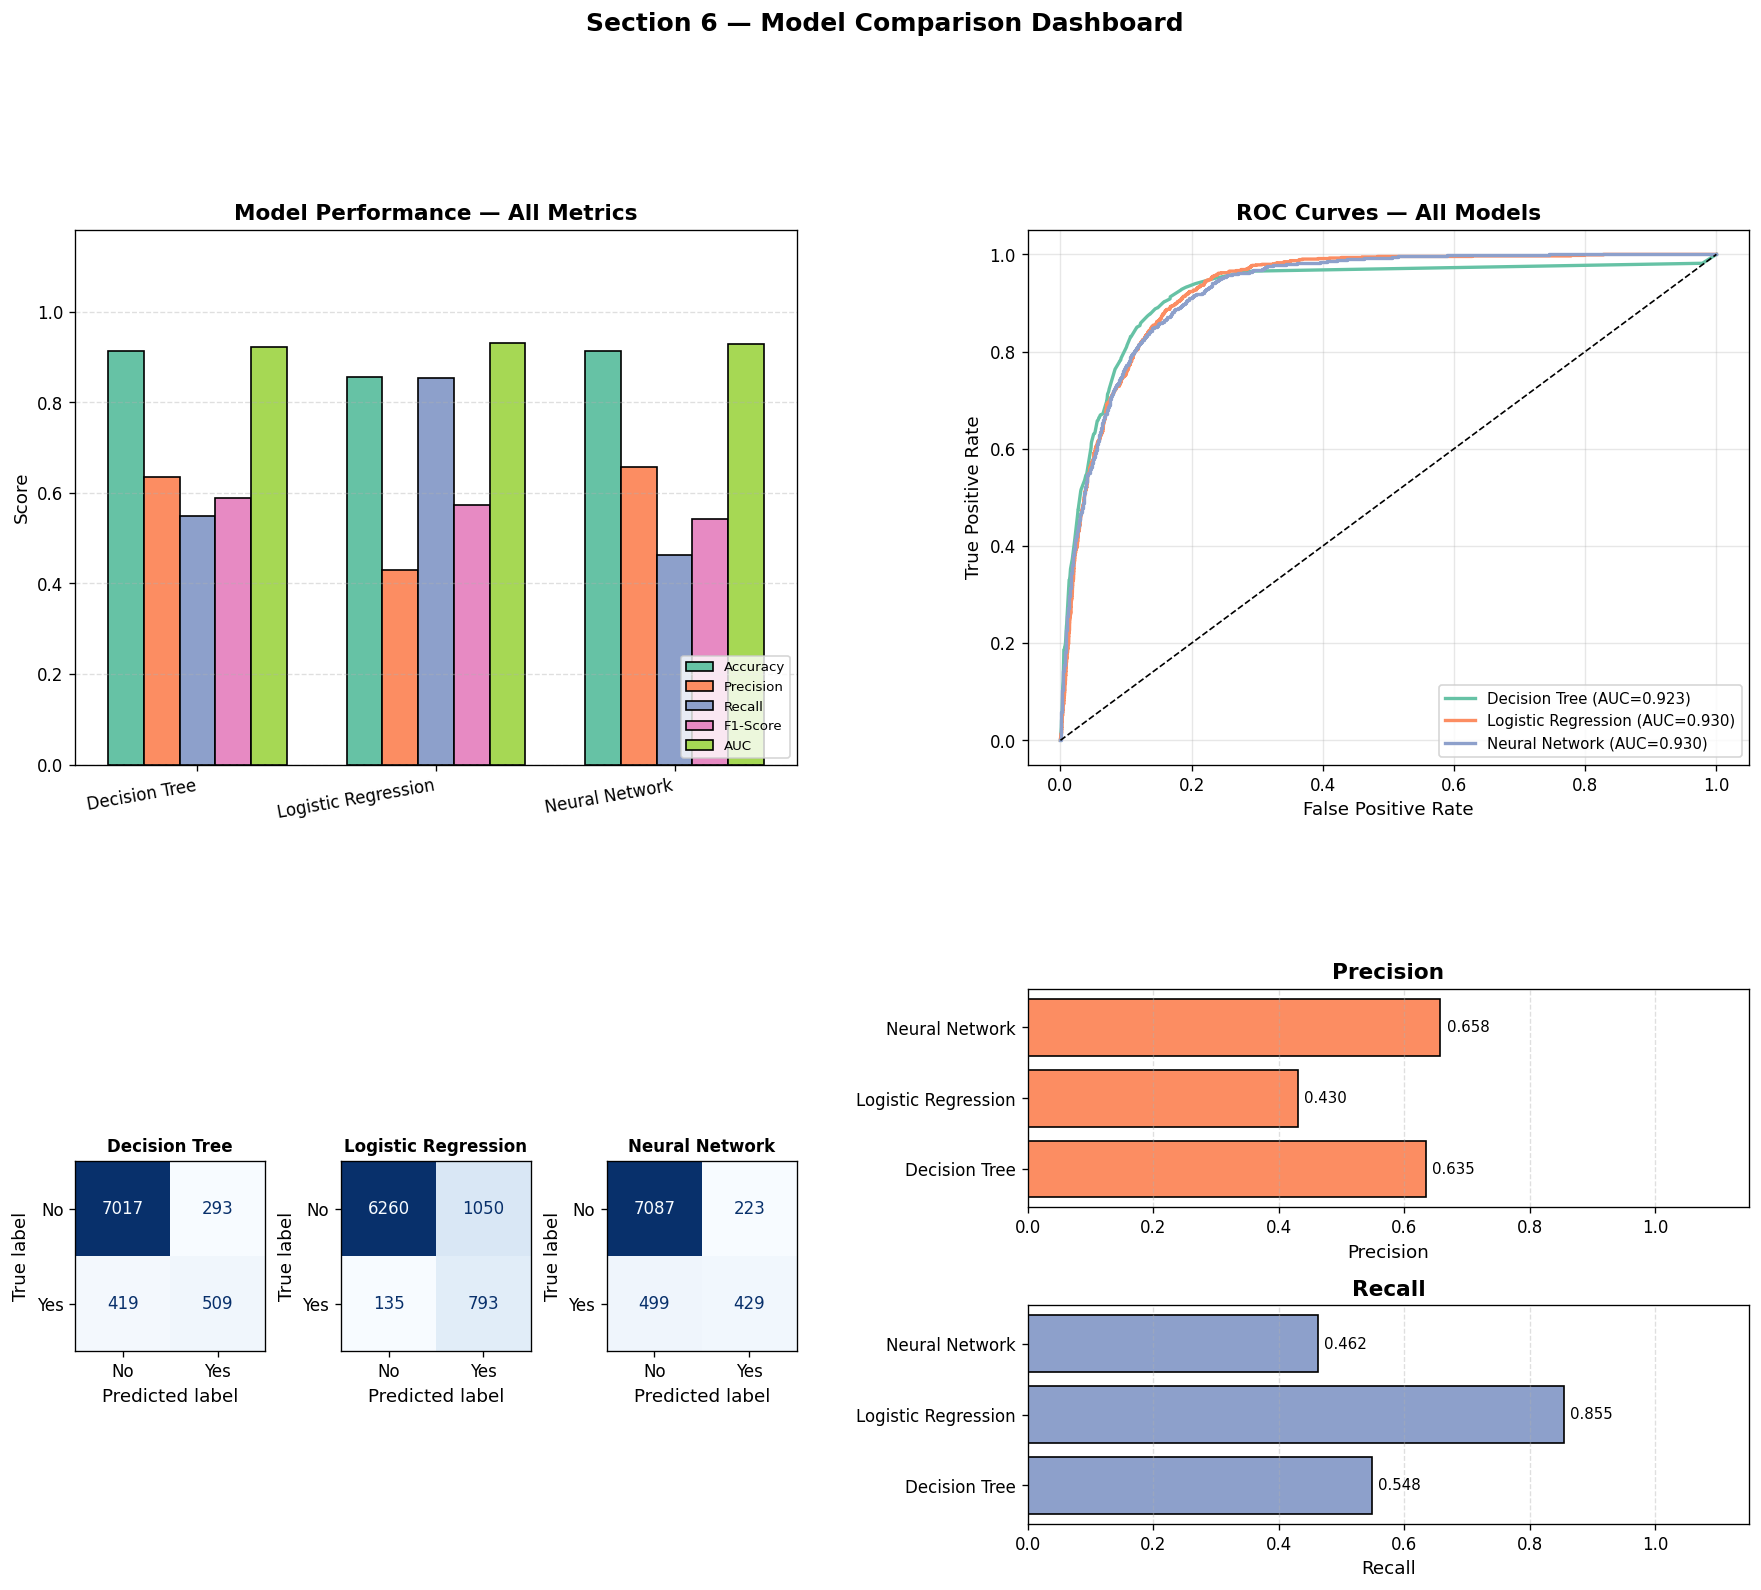


SECTION 7 - CONCLUSION

Key findings:
  - Dataset is heavily imbalanced (No: 88.8%, Yes: 11.2%).
    Raw accuracy alone is misleading - AUC and Recall matter more.
  - Best AUC     : Logistic Regression (0.9303)
  - Best Accuracy: Decision Tree (0.9136)
  - Decision Tree gives strong precision and is highly interpretable.
  - Logistic Regression (balanced weights) achieves the best recall -
    critical for not missing potential subscribers.
  - Neural Network captures complex non-linear patterns and scores
    highest overall across AUC and F1.
  - K-Means (k=2) reveals natural groupings partially aligned
    with subscription outcome; the PCA scatter shows cluster
    separation clearly in reduced 2D space.
  - Main challenge: class imbalance and the 'duration' feature
    (unknown before a call - potential data leakage risk).

All plots displayed inline above.
DONE.


In [ ]:
#Bank Marketing Model Training

from google.colab import files
uploaded = files.upload()


get_ipython().run_line_magic('matplotlib', 'inline')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
PALETTE = sns.color_palette("Set2")


# 1. LOAD DATA

print("=" * 65)
print("LOADING DATASET")
print("=" * 65)

df = pd.read_csv('Bank Marketing.csv')
print(f"Shape: {df.shape}  ({df.shape[0]} rows x {df.shape[1]} columns)")
print(df.head())


# 2. DATASET DESCRIPTION

print("\n" + "=" * 65)
print("SECTION 2 - DATASET DESCRIPTION")
print("=" * 65)

categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nTotal features  : {df.shape[1] - 1} (input) + 1 (output)")
print(f"Total data pts  : {df.shape[0]}")
print(f"Categorical cols: {categorical_cols}")
print(f"Numerical cols  : {numerical_cols}")
print("\nProblem type: CLASSIFICATION (binary - 'y': yes/no subscription)")

# Class distribution
class_counts = df['y'].value_counts()
print("\nClass distribution:")
print(class_counts)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(class_counts.index, class_counts.values,
              color=[PALETTE[0], PALETTE[1]], edgecolor='black', width=0.5)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Class Distribution of Target Variable (y)')
ax.set_xlabel('Subscribed Term Deposit')
ax.set_ylabel('Count')
ax.set_ylim(0, max(class_counts.values) * 1.15)
plt.tight_layout()
plt.show()

# Correlation heatmap
df_corr = df.copy()
df_corr['y_enc'] = LabelEncoder().fit_transform(df_corr['y'])
for col in categorical_cols:
    if col != 'y':
        df_corr[col + '_enc'] = LabelEncoder().fit_transform(df_corr[col])

heatmap_cols = numerical_cols + [c + '_enc' for c in categorical_cols if c != 'y'] + ['y_enc']
corr_matrix  = df_corr[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap (Full)', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# EDA: all numerical + categorical + box plots
num_features = list(numerical_cols)
cols_per_row = 4
rows_num = (len(num_features) + cols_per_row - 1) // cols_per_row
cat_input = [c for c in categorical_cols if c != 'y']
rows_cat = (len(cat_input) + cols_per_row - 1) // cols_per_row

# Figure 1: Numerical distributions
fig, axes = plt.subplots(rows_num, cols_per_row, figsize=(16, rows_num * 3.5))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color=PALETTE[i % len(PALETTE)], edgecolor='white')
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 2: Categorical vs target + Box plots
fig = plt.figure(figsize=(18, rows_cat * 3.5 + rows_num * 3.5))
gs  = gridspec.GridSpec(rows_cat + rows_num, cols_per_row, figure=fig,
                        hspace=0.55, wspace=0.35)

# Categorical bars (top section)
for i, col in enumerate(cat_input):
    row_i, col_i = divmod(i, cols_per_row)
    ax = fig.add_subplot(gs[row_i, col_i])
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=[PALETTE[0], PALETTE[1]],
            edgecolor='black', width=0.7, legend=(i == 0))
    ax.set_title(f'{col} vs Sub. Rate (%)', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    if i == 0:
        ax.legend(title='y', fontsize=7, loc='upper right')

# -- Box plots (bottom section)
for i, col in enumerate(num_features):
    row_i, col_i = divmod(i, cols_per_row)
    ax = fig.add_subplot(gs[rows_cat + row_i, col_i])
    df.boxplot(column=col, by='y', ax=ax,
               boxprops=dict(color=PALETTE[0]),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('y', fontsize=9)
    plt.sca(ax); plt.title(col, fontsize=10)

fig.suptitle('EDA — Categorical vs Subscription Rate  |  Numerical by Target Class',
             fontsize=13, fontweight='bold', y=1.005)
plt.show()


# 3. DATA PREPROCESSING

print("\n" + "=" * 65)
print("SECTION 3 - DATA PREPROCESSING")
print("=" * 65)

df_proc = df.copy()
print(f"\nMissing values: {df_proc.isnull().sum().sum()} -> No action needed")

print("\nLabel Encoding categorical features:")
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col])
    label_encoders[col] = le
    print(f"  {col}: {list(le.classes_)}")

X = df_proc.drop(columns=['y'])
y = df_proc['y']
print(f"\nFeatures shape: {X.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("StandardScaler applied - mean~0, std~1")


# 4. DATASET SPLITTING (Stratified 80/20)

print("\n" + "=" * 65)
print("SECTION 4 - DATASET SPLITTING")
print("=" * 65)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=1, stratify=y
)
print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Train class ratio: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test  class ratio: {pd.Series(y_test).value_counts().to_dict()}")


# 5. MODEL TRAINING & TESTING

print("\n" + "=" * 65)
print("SECTION 5 - MODEL TRAINING & TESTING")
print("=" * 65)

results = {}

def evaluate(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)
    cm   = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    print(f"\n[{name}]")
    print(f"  Accuracy : {acc:.4f}  |  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}  |  F1-Score : {f1:.4f}")
    print(f"  AUC      : {auc:.4f}")
    results[name] = dict(model=model, acc=acc, prec=prec, rec=rec,
                         f1=f1, auc=auc, cm=cm, fpr=fpr, tpr=tpr)

# Model 1 - Decision Tree
evaluate('Decision Tree',
         DecisionTreeClassifier(max_depth=8, random_state=42))

# Model 2 - Logistic Regression
evaluate('Logistic Regression',
         LogisticRegression(max_iter=500, random_state=42, class_weight='balanced'))

# Model 3 - Neural Network (MLP)
evaluate('Neural Network',
         MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                       solver='adam', max_iter=200, random_state=42,
                       early_stopping=True, validation_fraction=0.1))


# UNSUPERVISED - K-Means Clustering

print("\n" + "-" * 55)
print("UNSUPERVISED - K-Means Clustering")
print("-" * 55)

inertias, sil_scores = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_, sample_size=5000))

# Elbow + Silhouette in one figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, 'bo-')
axes[0].set_title('Elbow Method - Inertia vs k')
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_range), sil_scores, 'rs-')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout(); plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"  Best k: {best_k}  |  Silhouette Score: {max(sil_scores):.4f}")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

cluster_df  = pd.DataFrame({'Cluster': cluster_labels, 'True Label': y.values})
composition = cluster_df.groupby(['Cluster', 'True Label']).size().unstack(fill_value=0)
composition.columns = ['No (0)', 'Yes (1)']
print("\nCluster Composition vs True Labels:")
print(composition)

# K-Means Scatter Plot (PCA 2D projection)
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)
var_exp  = pca.explained_variance_ratio_ * 100

CLUSTER_COLORS = sns.color_palette("tab10", best_k)
MARKERS        = {0: 'o', 1: '^'}
LABEL_NAMES    = {0: 'No', 1: 'Yes'}


rng    = np.random.default_rng(42)
idx    = rng.choice(len(X_pca), size=min(4000, len(X_pca)), replace=False)
X_vis  = X_pca[idx]
cl_vis = cluster_labels[idx]
tl_vis = y.values[idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left panel — coloured by K-Means cluster
for c in range(best_k):
    mask = cl_vis == c
    axes[0].scatter(X_vis[mask, 0], X_vis[mask, 1],
                    color=CLUSTER_COLORS[c], alpha=0.55, s=18,
                    edgecolors='none', label=f'Cluster {c}')
axes[0].set_title(f'K-Means Clusters (k={best_k}) — PCA Projection', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.1f}% var)')
axes[0].legend(title='Cluster', fontsize=9, markerscale=1.4)
axes[0].grid(True, alpha=0.25)

# Right panel — coloured by cluster, shaped by true label
for c in range(best_k):
    for lbl, marker in MARKERS.items():
        mask = (cl_vis == c) & (tl_vis == lbl)
        axes[1].scatter(X_vis[mask, 0], X_vis[mask, 1],
                        color=CLUSTER_COLORS[c], marker=marker,
                        alpha=0.55, s=20, edgecolors='none',
                        label=f'C{c} / {LABEL_NAMES[lbl]}' if c == 0 else '_')

from matplotlib.lines import Line2D
color_handles  = [Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=CLUSTER_COLORS[c], markersize=8,
                          label=f'Cluster {c}') for c in range(best_k)]
marker_handles = [Line2D([0], [0], marker=m, color='gray', markersize=8,
                          label=f'True: {LABEL_NAMES[l]}')
                  for l, m in MARKERS.items()]
axes[1].legend(handles=color_handles + marker_handles, fontsize=8,
               title='Cluster / True Label', ncol=2)
axes[1].set_title('Cluster vs True Label (shape=subscription)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var_exp[0]:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]:.1f}% var)')
axes[1].grid(True, alpha=0.25)

plt.suptitle('K-Means Clustering — 2D PCA Scatter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. MODEL COMPARISON  — single combined figure

print("\n" + "=" * 65)
print("SECTION 6 - MODEL COMPARISON")
print("=" * 65)

model_names = list(results.keys())
accs  = [results[m]['acc']  for m in model_names]
precs = [results[m]['prec'] for m in model_names]
recs  = [results[m]['rec']  for m in model_names]
f1s   = [results[m]['f1']   for m in model_names]
aucs  = [results[m]['auc']  for m in model_names]

summary = pd.DataFrame({
    'Model'    : model_names,
    'Accuracy' : [f"{v:.4f}" for v in accs],
    'Precision': [f"{v:.4f}" for v in precs],
    'Recall'   : [f"{v:.4f}" for v in recs],
    'F1-Score' : [f"{v:.4f}" for v in f1s],
    'AUC'      : [f"{v:.4f}" for v in aucs],
})
print("\nSummary Table:")
print(summary.to_string(index=False))



fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

#  A: Grouped bar chart (top-left)
ax_bar = fig.add_subplot(gs[0, 0])
x     = np.arange(len(model_names))
width = 0.15
ax_bar.bar(x - 2*width, accs,  width, label='Accuracy',  color=PALETTE[0], edgecolor='black')
ax_bar.bar(x - 1*width, precs, width, label='Precision', color=PALETTE[1], edgecolor='black')
ax_bar.bar(x,           recs,  width, label='Recall',    color=PALETTE[2], edgecolor='black')
ax_bar.bar(x + 1*width, f1s,   width, label='F1-Score',  color=PALETTE[3], edgecolor='black')
ax_bar.bar(x + 2*width, aucs,  width, label='AUC',       color=PALETTE[4], edgecolor='black')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(model_names, rotation=10, ha='right')
ax_bar.set_ylim(0, 1.18)
ax_bar.set_ylabel('Score')
ax_bar.set_title('Model Performance — All Metrics', fontweight='bold')
ax_bar.legend(loc='lower right', fontsize=8)
ax_bar.grid(axis='y', linestyle='--', alpha=0.4)

# B: ROC curves (top-right)
ax_roc = fig.add_subplot(gs[0, 1])
for i, name in enumerate(model_names):
    ax_roc.plot(results[name]['fpr'], results[name]['tpr'],
                label=f"{name} (AUC={results[name]['auc']:.3f})",
                color=PALETTE[i], lw=2)
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves — All Models', fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=9)
ax_roc.grid(True, alpha=0.3)

# C: Confusion matrices(bottom-left)
gs_cm   = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1, 0],
                                           hspace=0.5, wspace=0.4)
for i, name in enumerate(model_names):
    ax_cm = fig.add_subplot(gs_cm[0, i])
    disp  = ConfusionMatrixDisplay(results[name]['cm'], display_labels=['No', 'Yes'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title(name, fontweight='bold', fontsize=10)

# D: Precision & Recall horizontal bars(bottom-right)
gs_pr  = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1, 1],
                                          hspace=0.45)
ax_p   = fig.add_subplot(gs_pr[0])
ax_r   = fig.add_subplot(gs_pr[1])

ax_p.barh(model_names, precs, color=PALETTE[1], edgecolor='black')
ax_p.set_xlim(0, 1.15); ax_p.set_title('Precision', fontweight='bold')
ax_p.set_xlabel('Precision'); ax_p.grid(axis='x', linestyle='--', alpha=0.4)
for i, v in enumerate(precs):
    ax_p.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

ax_r.barh(model_names, recs, color=PALETTE[2], edgecolor='black')
ax_r.set_xlim(0, 1.15); ax_r.set_title('Recall', fontweight='bold')
ax_r.set_xlabel('Recall'); ax_r.grid(axis='x', linestyle='--', alpha=0.4)
for i, v in enumerate(recs):
    ax_r.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

fig.suptitle('Section 6 — Model Comparison Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.show()


# 7. CONCLUSION

print("\n" + "=" * 65)
print("SECTION 7 - CONCLUSION")
print("=" * 65)

best_auc_m = model_names[aucs.index(max(aucs))]
best_acc_m = model_names[accs.index(max(accs))]

print(f"""
Key findings:
  - Dataset is heavily imbalanced (No: 88.8%, Yes: 11.2%).
    Raw accuracy alone is misleading - AUC and Recall matter more.
  - Best AUC     : {best_auc_m} ({max(aucs):.4f})
  - Best Accuracy: {best_acc_m} ({max(accs):.4f})
  - Decision Tree gives strong precision and is highly interpretable.
  - Logistic Regression (balanced weights) achieves the best recall -
    critical for not missing potential subscribers.
  - Neural Network captures complex non-linear patterns and scores
    highest overall across AUC and F1.
  - K-Means (k={best_k}) reveals natural groupings partially aligned
    with subscription outcome; the PCA scatter shows cluster
    separation clearly in reduced 2D space.
  - Main challenge: class imbalance and the 'duration' feature
    (unknown before a call - potential data leakage risk).
""")

print("All plots displayed inline above.")
print("DONE.")